In [20]:
import os
from pathlib import Path

from dotenv import load_dotenv
import pandas as pd
import yaml

from src.tools.read.analyze_embeddings.load_analyze_embeddings import load_analyze_embeddings



load_dotenv()

ANALYZE_EMBEDDINGS_DIR = Path(os.getenv("ANALYZE_EMBEDDINGS_DIR"))


embedding_df = load_analyze_embeddings(ANALYZE_EMBEDDINGS_DIR)

# metric_cols = [
#     "Accuracy@1",
#     "Accuracy@2",
#     "Accuracy@3",
#     "Accuracy@4",
#     "Accuracy@5",
#     "Recall@10",
#     "MRR@10",
#     "NDCG@10",
#     "rerank_result_time",
# ]

# # reszta kolumn
# other_cols = [c for c in retrieval_df.columns if c not in metric_cols]

# retrieval_df

In [21]:
embedding_df = embedding_df[~embedding_df.index.droplevel("embed_params_name").duplicated()]

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import math


def plot_metrics_subplots(df, metric_cols, ncols=2):

    labels = [
        " | ".join(map(str, idx))
        for idx in df.index
    ]

    n_metrics = len(metric_cols)
    nrows = math.ceil(n_metrics / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(6 * ncols, 4 * nrows),
        constrained_layout=True
    )

    axes = np.array(axes).reshape(-1)

    x = np.arange(len(df))

    # kolory automatyczne z matplotlib
    colors = plt.cm.tab20(np.linspace(0, 1, len(df)))

    for ax, metric in zip(axes, metric_cols):

        for i, (label, color) in enumerate(zip(labels, colors)):
            ax.bar(
                i,
                df.iloc[i][metric],
                color=color,
                label=label if metric == metric_cols[0] else None
            )

        ax.set_title(metric)
        ax.set_ylim(0, 1)

        # ukryj x ticki
        ax.set_xticks([])

    # usuń puste subploty
    for ax in axes[n_metrics:]:
        fig.delaxes(ax)

    # wspólna legenda
    fig.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5)
    )

    return fig, axes

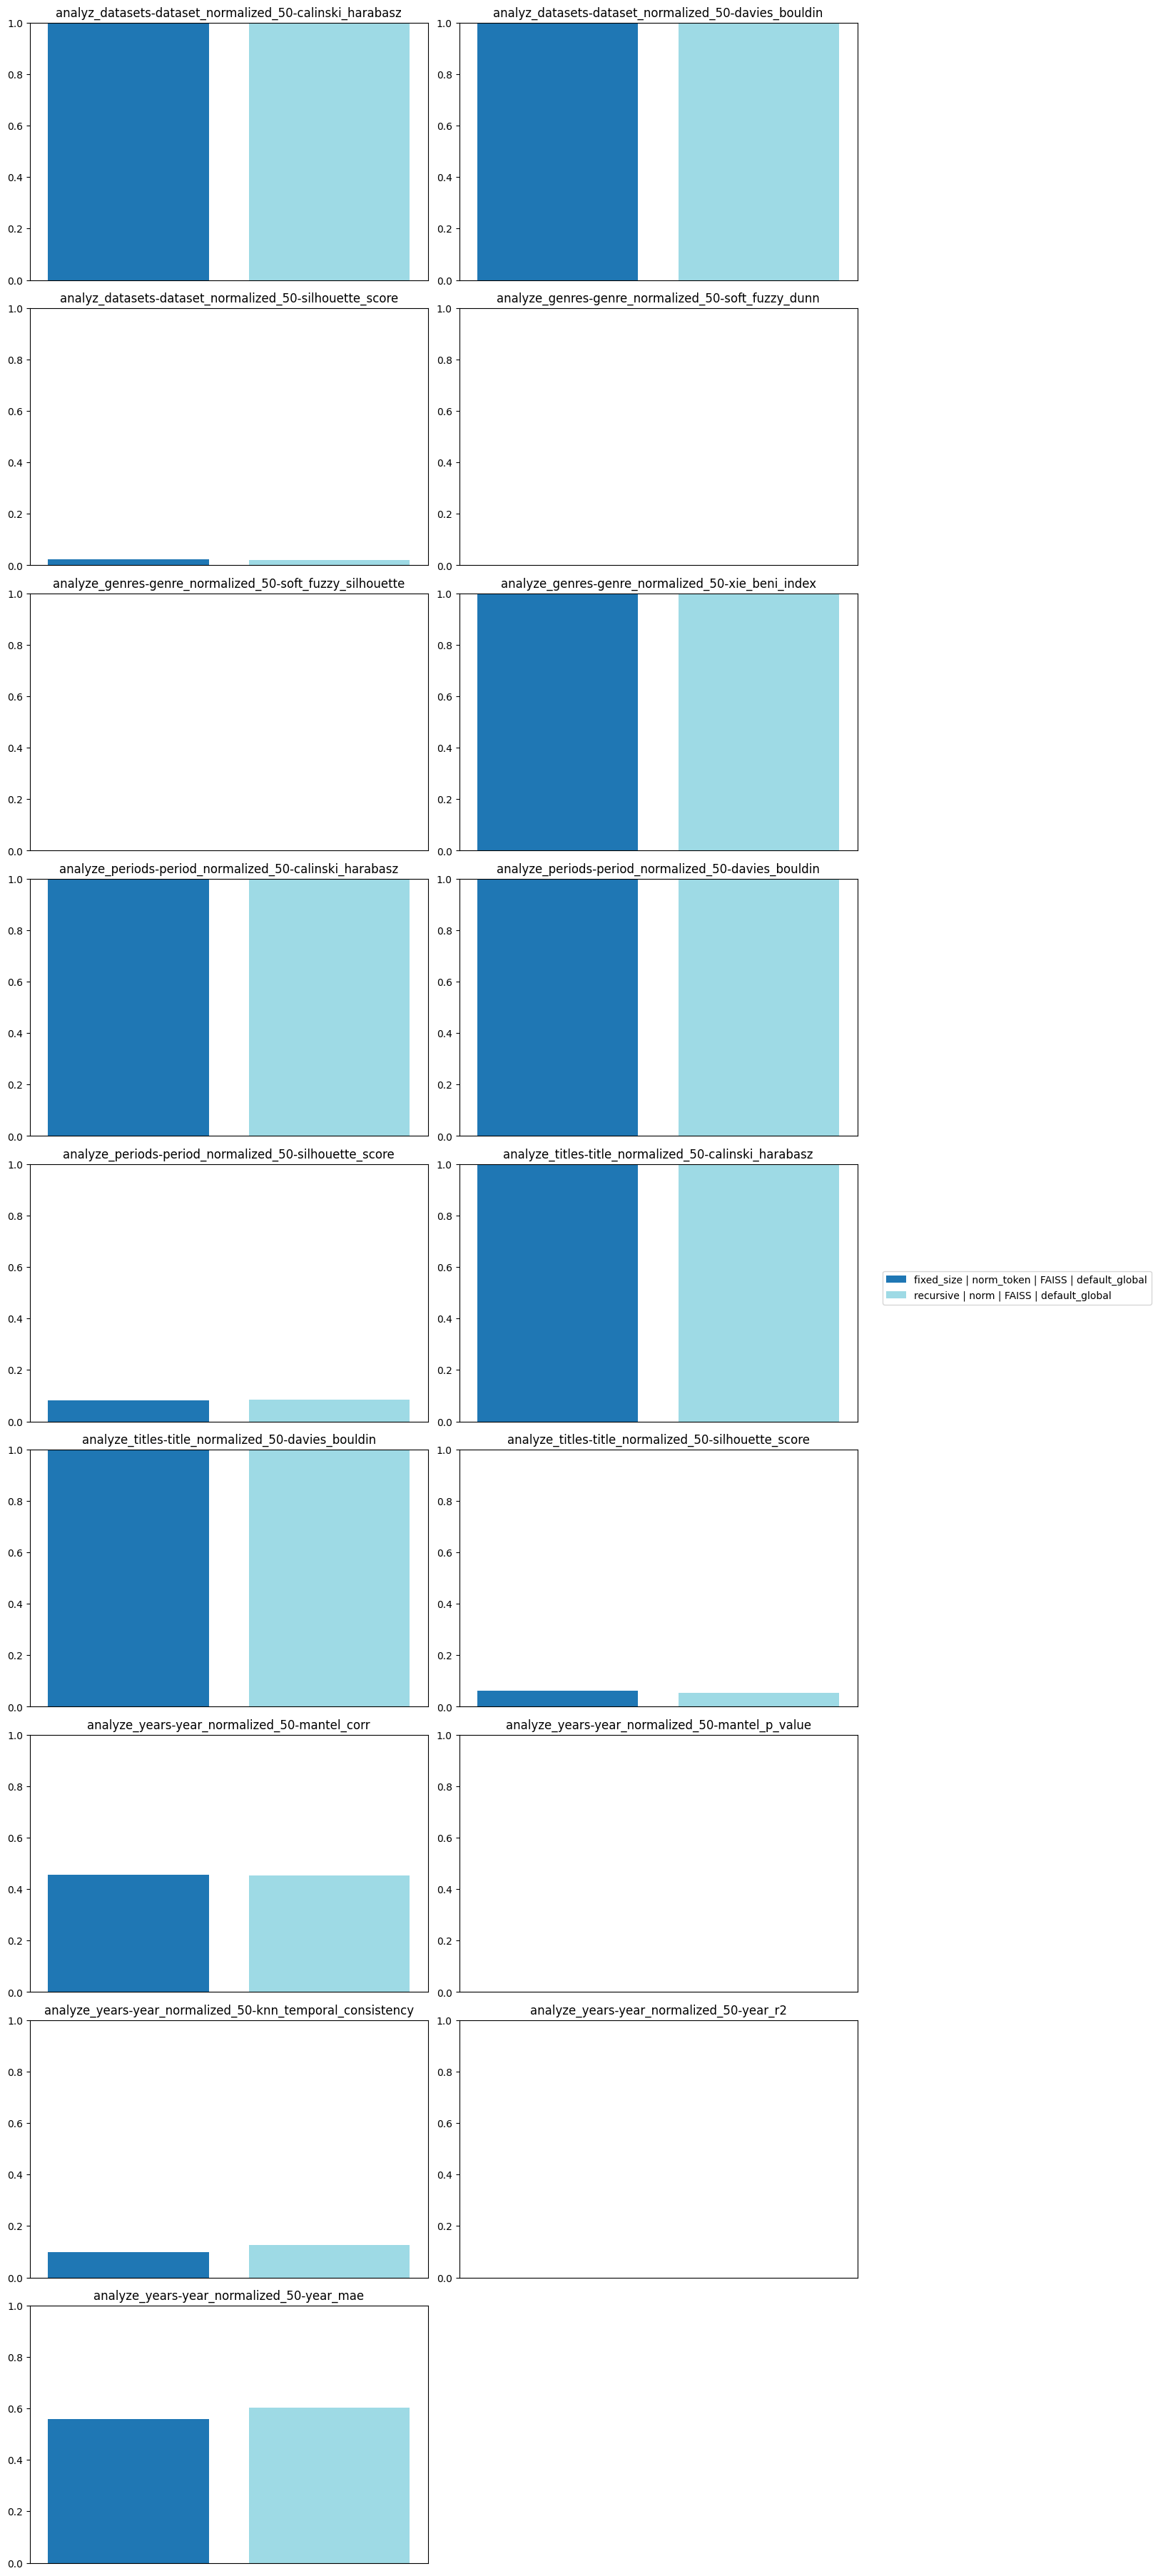

In [24]:
cols = [
    col
    for col in embedding_df.columns
    if "label_counts" not in col
]
fig, axes = plot_metrics_subplots(embedding_df, cols)
plt.show()